In [1]:
print("Hello!")

Hello!


In [2]:
from modules.viz import MultiExperiment, metric_x_point
import numpy as np

In [3]:
# g2a = MultiExperiment(
#     experiment_dirs=[
#         'output/2025-12-27_14h38m29s_grid_2a_reconstr_norm'
#     ],
#     keys=['norm_class','libnorm','znorm','learnable'],
#     out_dir='./experiments/grid_2_reconstr_norm',
#     # overwrite=True
# )

g2a = MultiExperiment(
    experiment_dirs=[
        'output/2026-01-02_16h03m38s_grid_2b_NBreconstr_norm'
    ],
    keys=['norm_class','libnorm','znorm','learnable'],
    out_dir='./experiments/grid_2b_reconstr_norm',
    # overwrite=True
)

Avoided overwriting 28 files. Call self.avoided_overwrite to see list, or run with overwrite=True to overwrite.


In [4]:
print(len(g2a.configs))
g2a.configs

24


,norm_class,libnorm,znorm,learnable,config
0,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...
1,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...
2,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...
3,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...
4,RawCounts,True,False,False,normclassRawCounts_libnormTrue_znormFalse_lear...
5,RawCounts,True,False,True,normclassRawCounts_libnormTrue_znormFalse_lear...
6,RawCounts,True,True,False,normclassRawCounts_libnormTrue_znormTrue_learn...
7,RawCounts,True,True,True,normclassRawCounts_libnormTrue_znormTrue_learn...
8,LogCounts,False,False,False,normclassLogCounts_libnormFalse_znormFalse_lea...
9,LogCounts,False,False,True,normclassLogCounts_libnormFalse_znormFalse_lea...


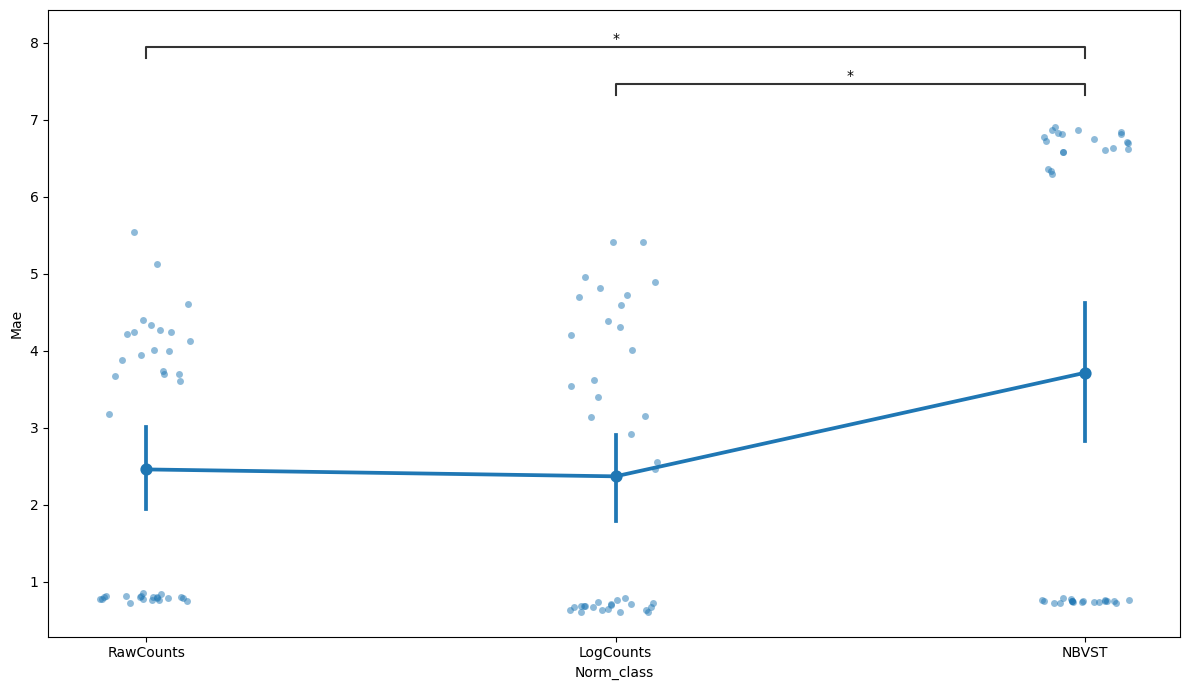

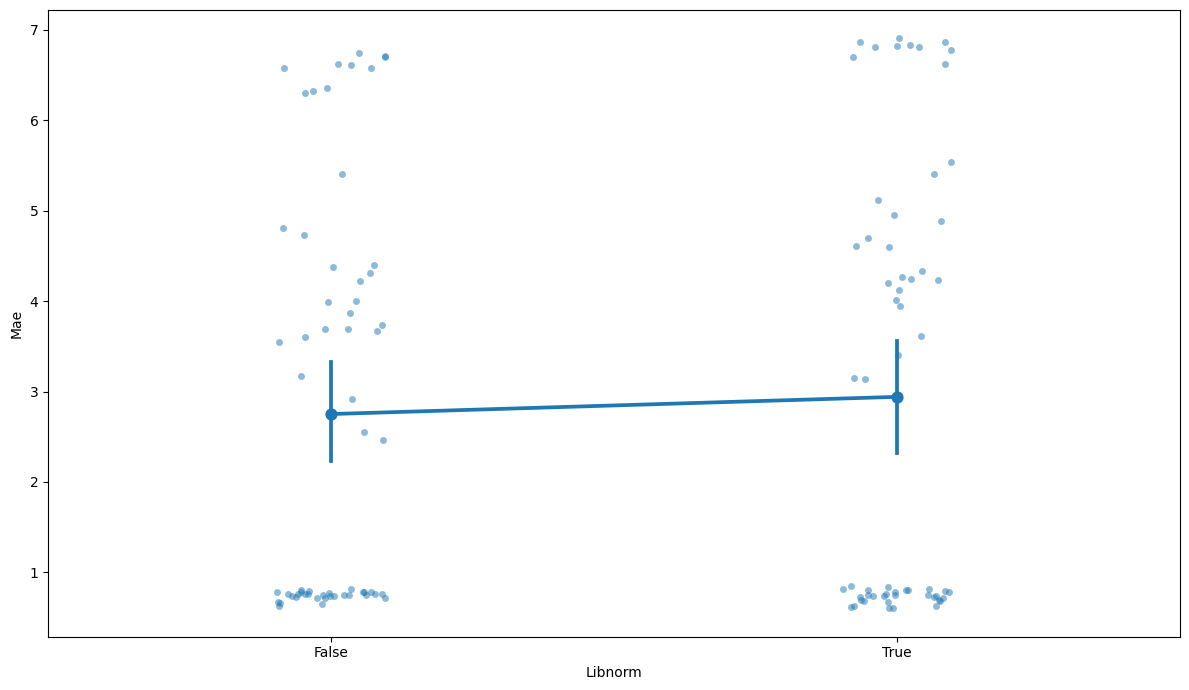

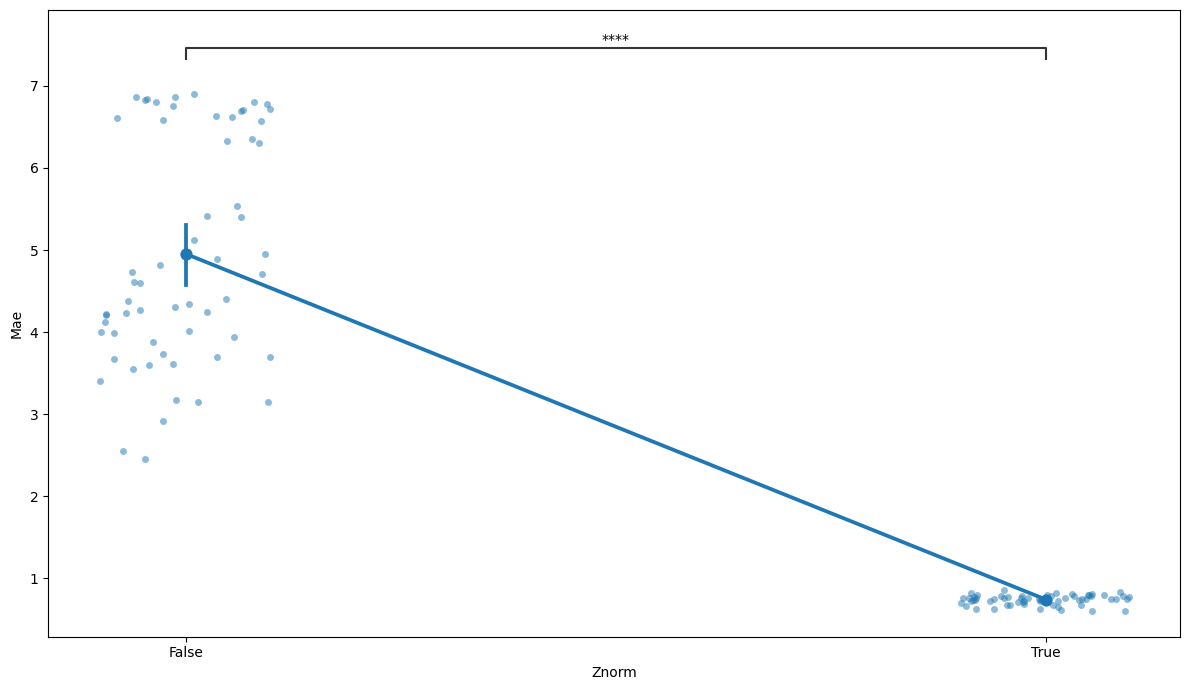

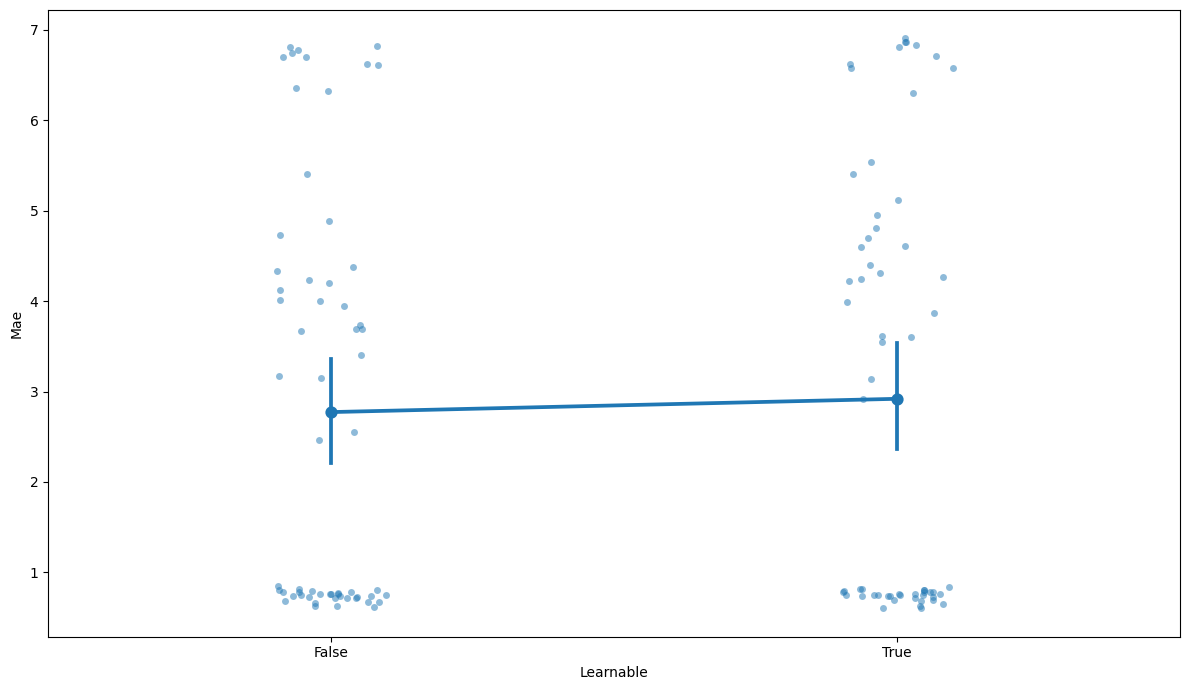

In [5]:
metric_x_point(
    df=g2a.test,
    cols=g2a.keys,
    metrics=['mae'],
    figsize=(12,7),
    strip=True
)

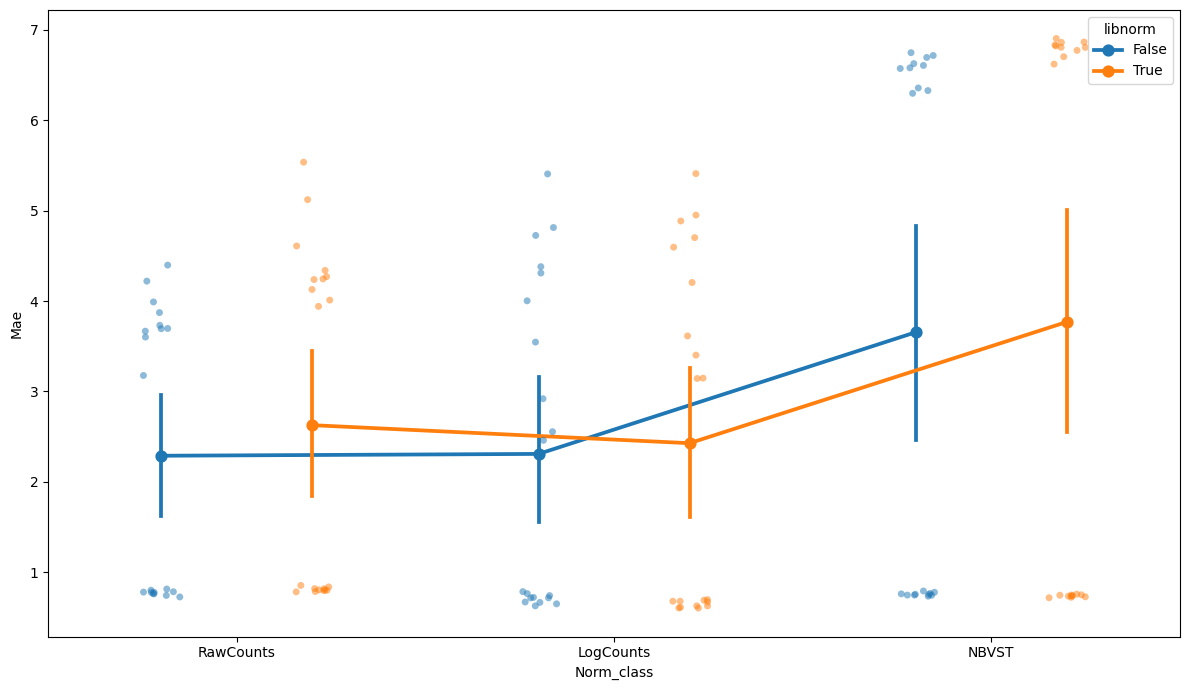

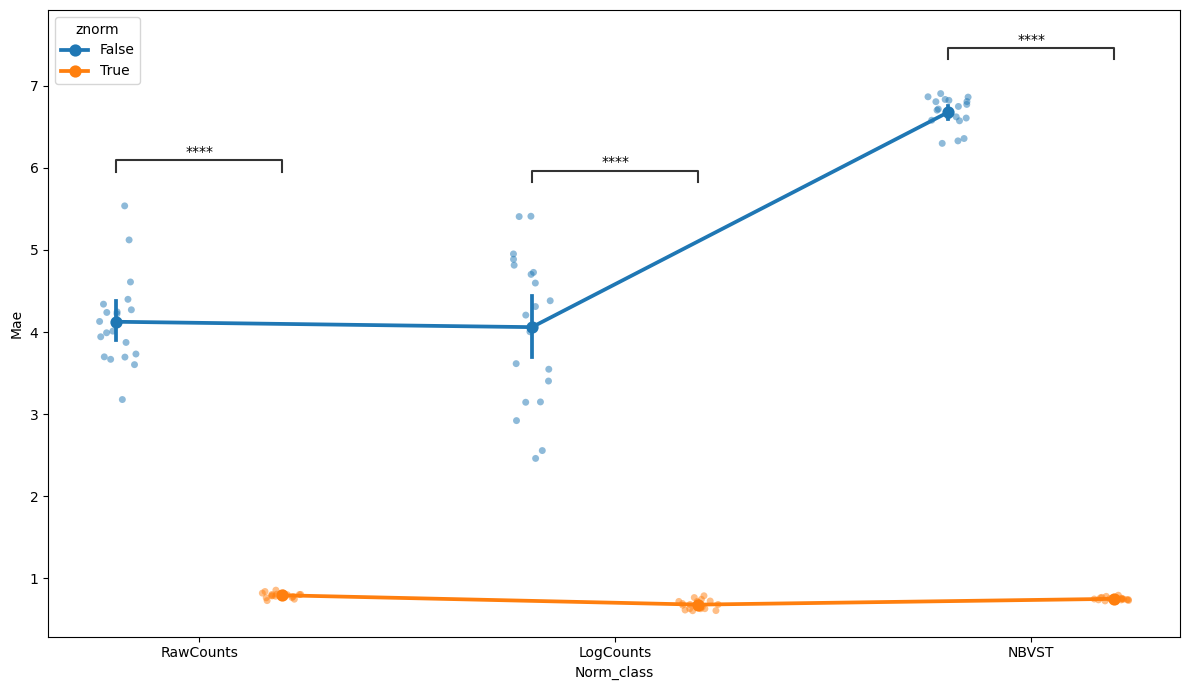

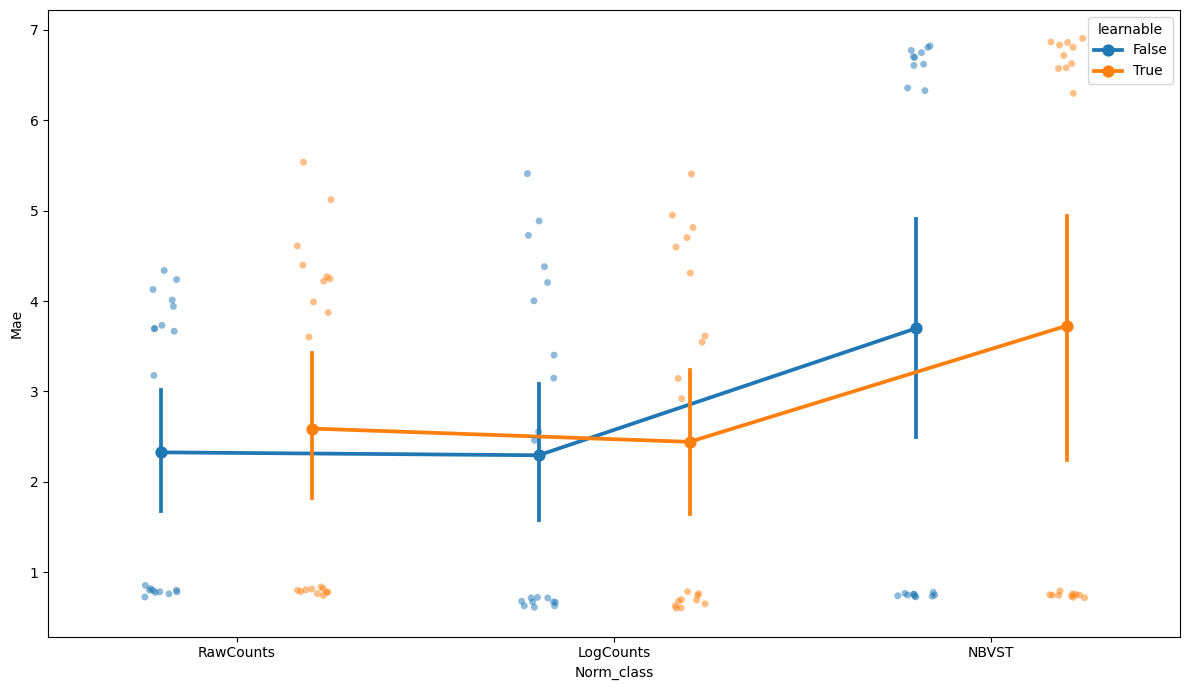

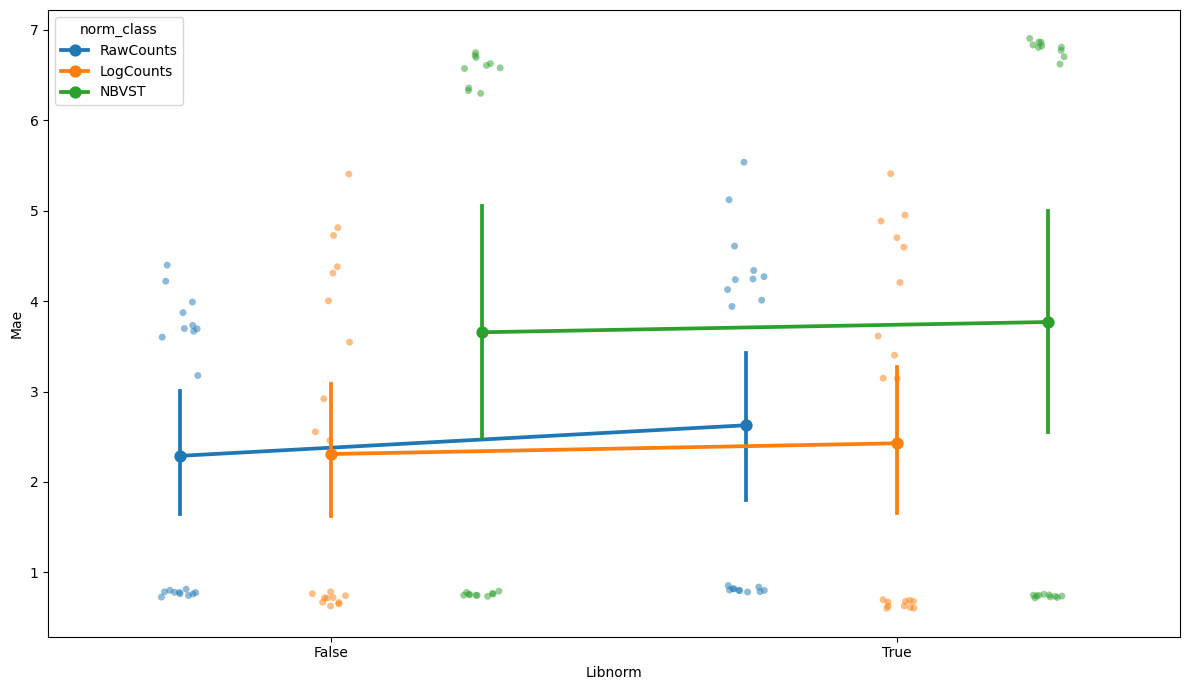

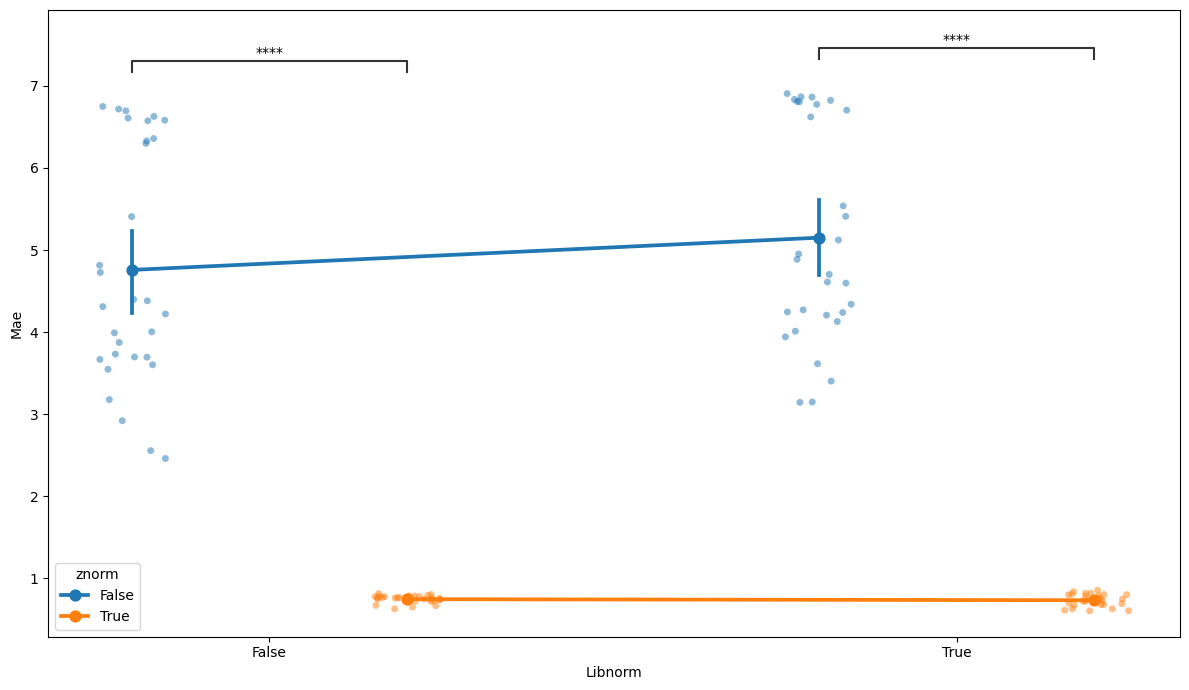

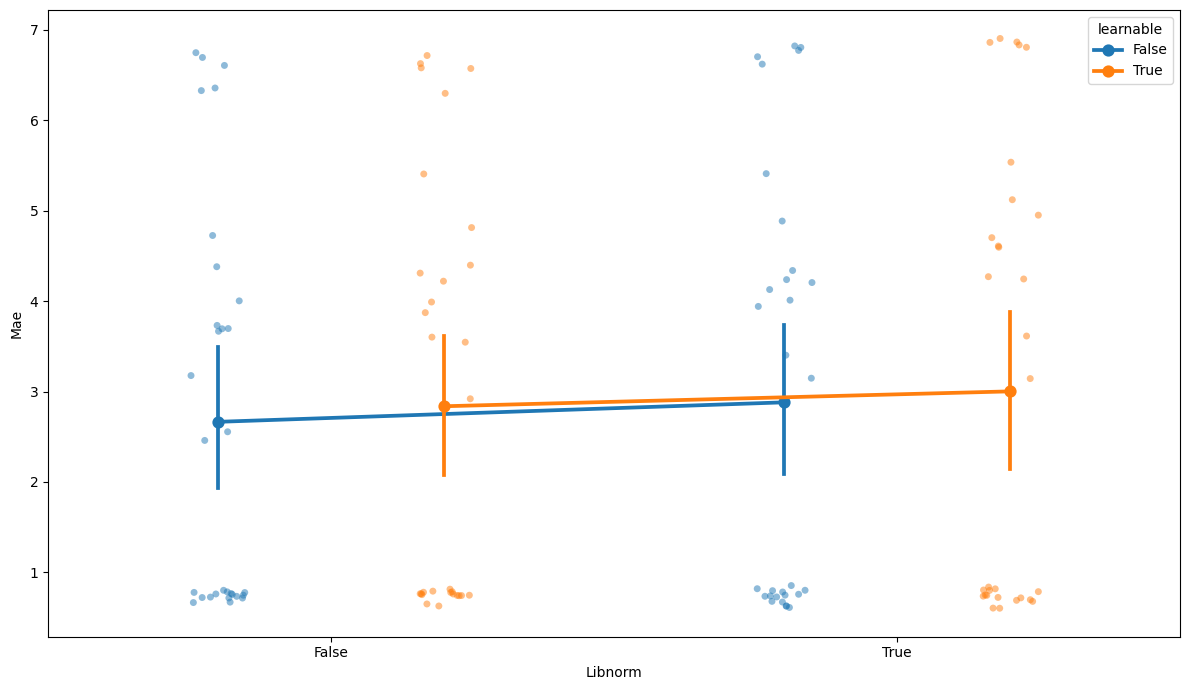

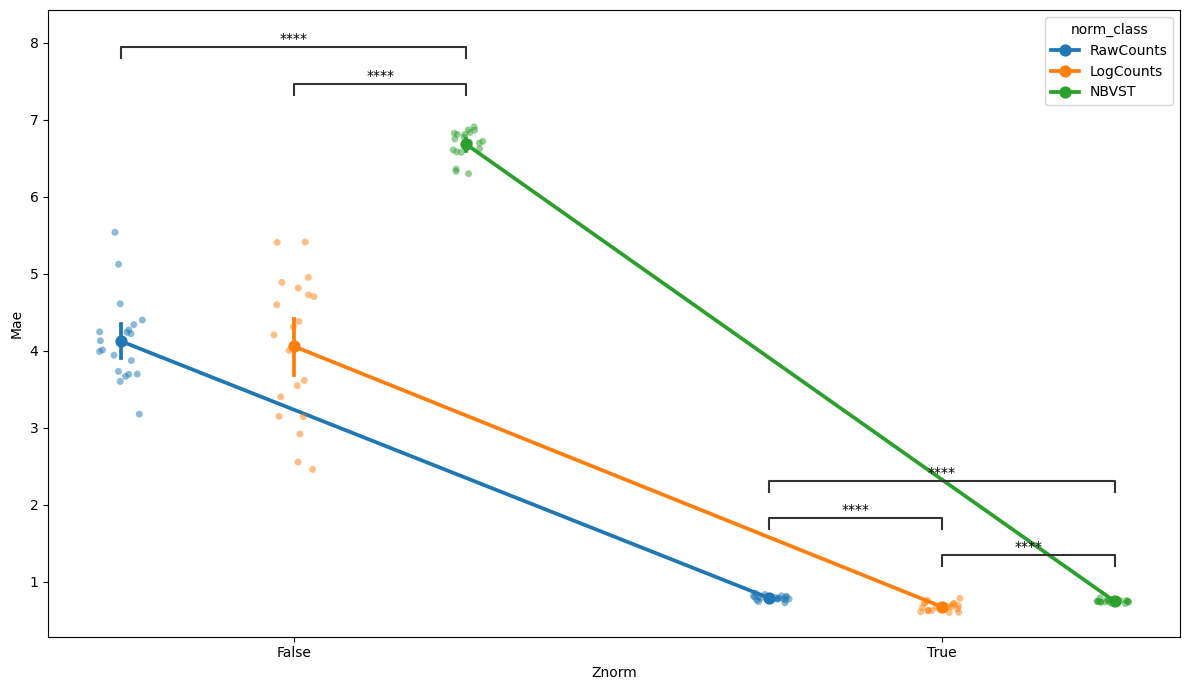

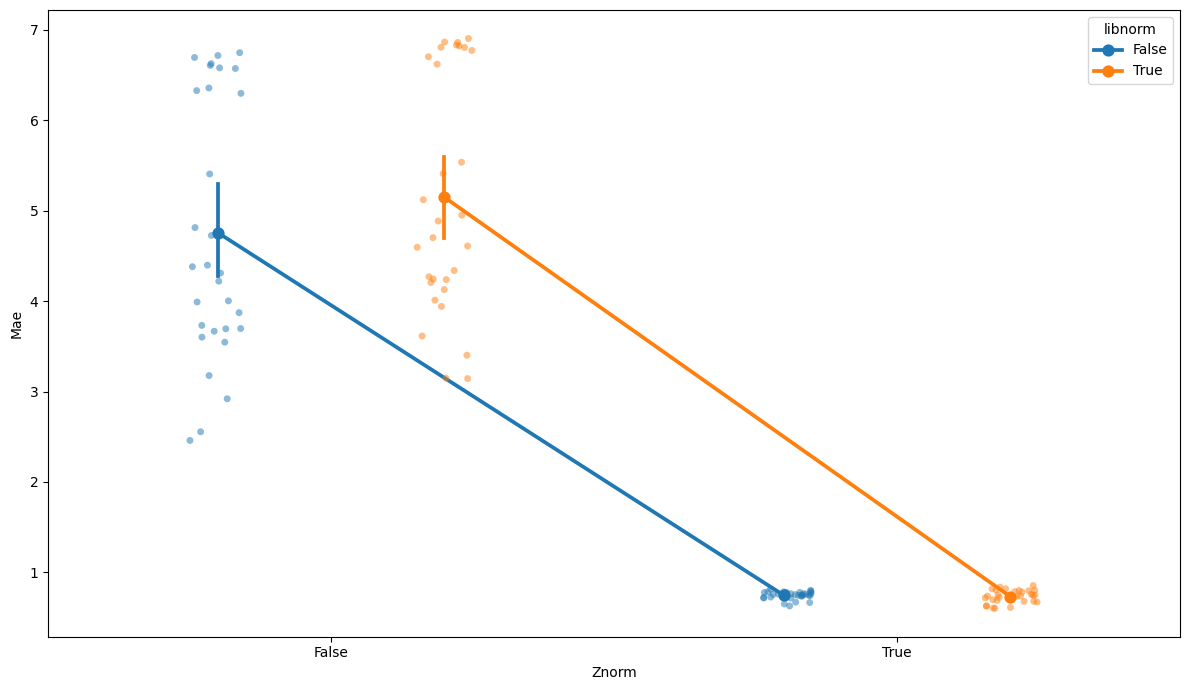

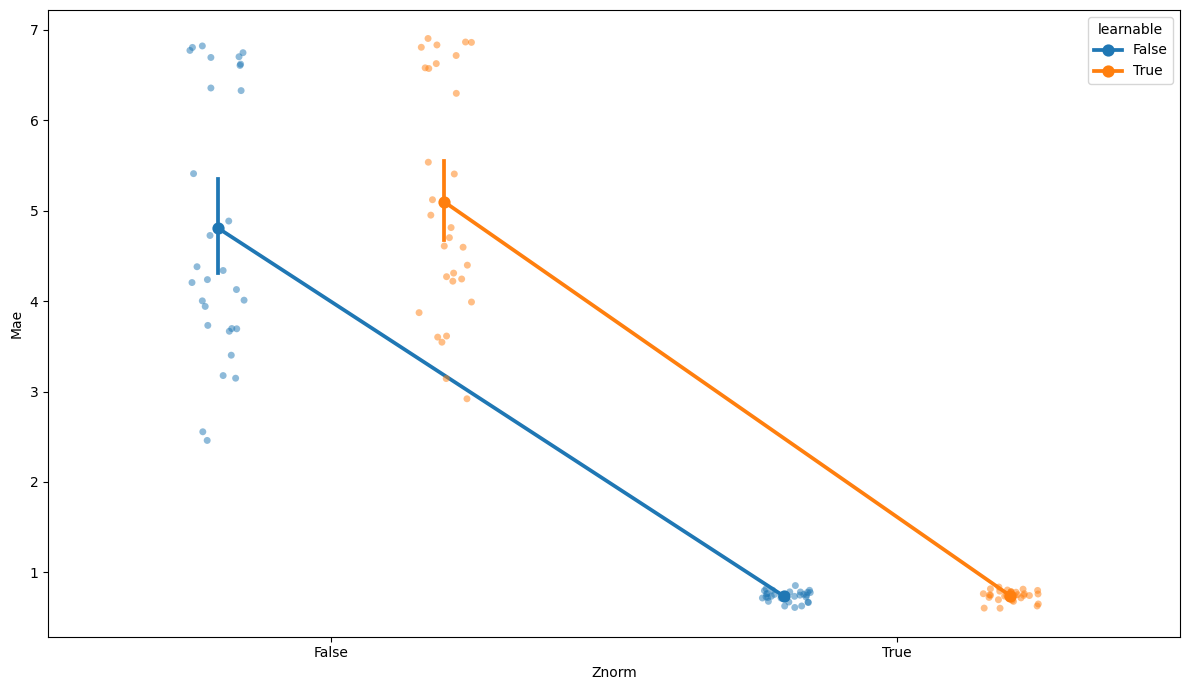

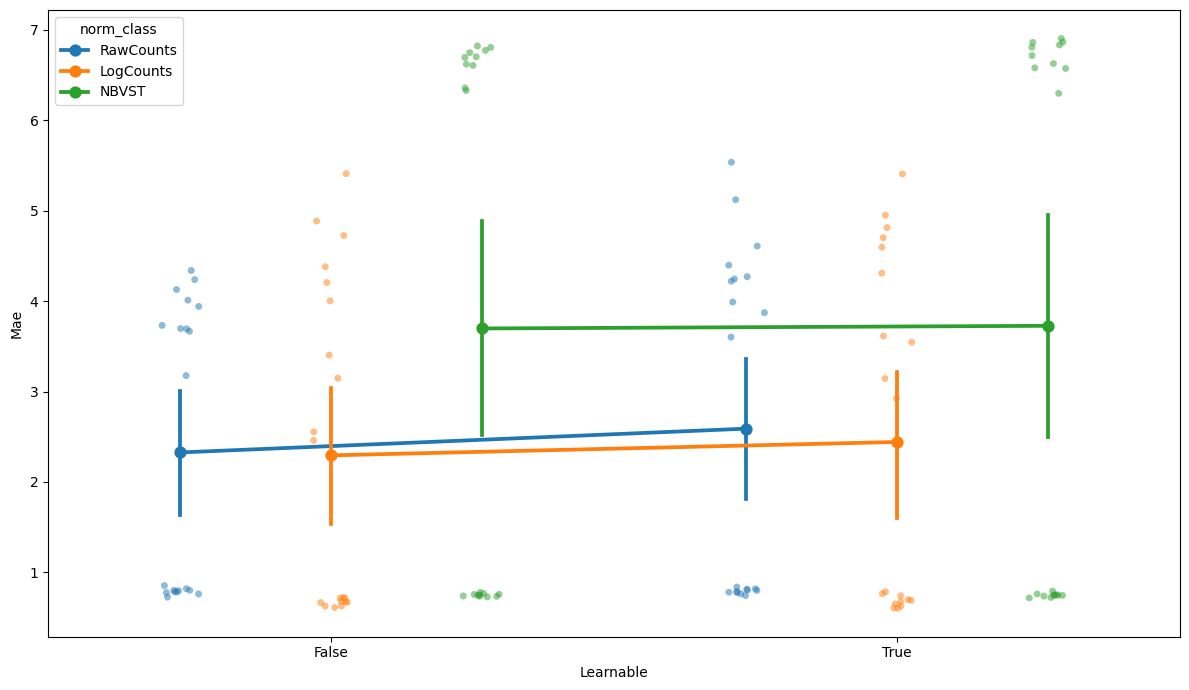

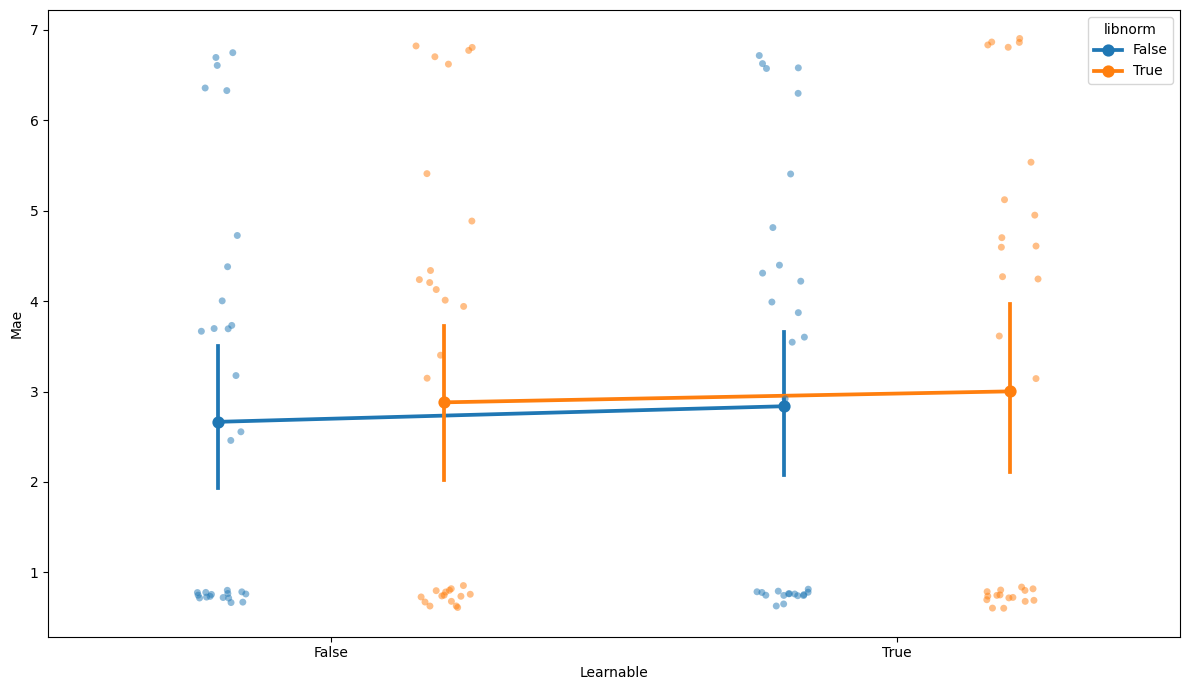

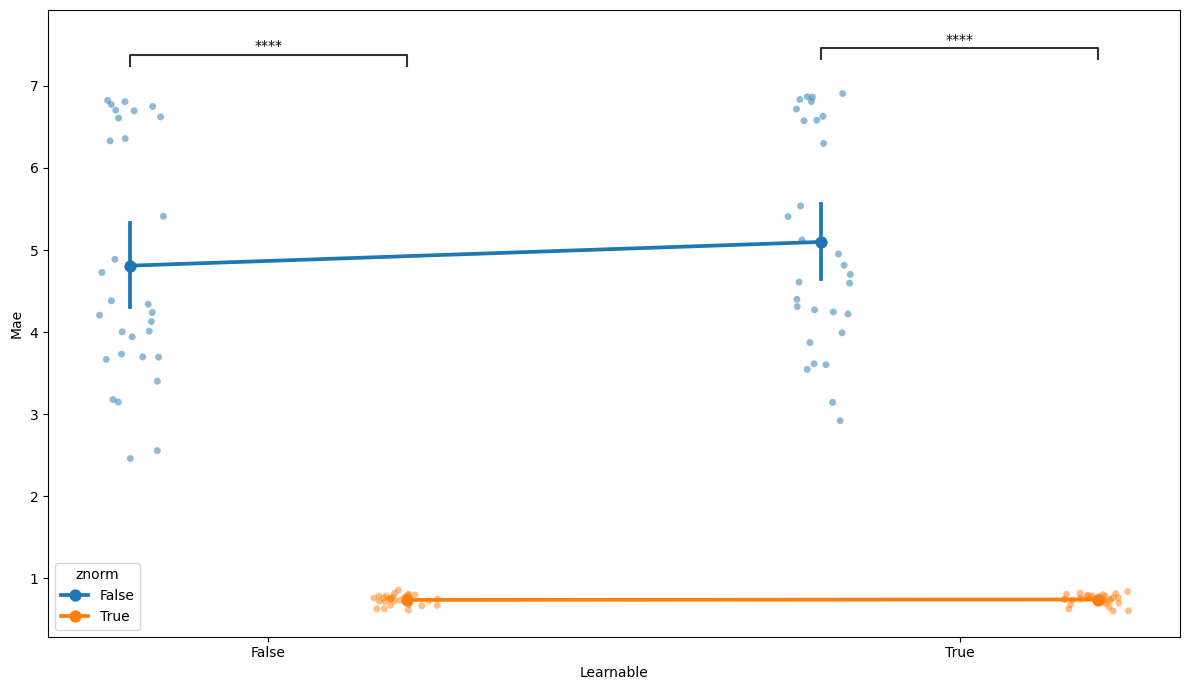

In [6]:
metric_x_point(
    df=g2a.test,
    cols=g2a.keys,
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    hue=True
)

---

In [7]:
# final thesis
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from statannotations.Annotator import Annotator

In [8]:
df = g2a.test.copy()
df = df[df['metric'] == 'mae']
display(df.head(10))

df2 = g2a.test[~(g2a.test['znorm']==False)].copy()
df2 = df2[df2['metric'] == 'mae']
display(df2.head(10))

,norm_class,libnorm,znorm,learnable,config,trial,metric,value
3,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...,0,mae,3.667249
12,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...,1,mae,3.177203
21,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...,2,mae,3.694426
30,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...,3,mae,3.731931
39,RawCounts,False,False,False,normclassRawCounts_libnormFalse_znormFalse_lea...,4,mae,3.697323
48,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...,0,mae,3.602278
57,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...,1,mae,3.990648
66,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...,2,mae,3.873092
75,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...,3,mae,4.398334
84,RawCounts,False,False,True,normclassRawCounts_libnormFalse_znormFalse_lea...,4,mae,4.220978


,norm_class,libnorm,znorm,learnable,config,trial,metric,value
93,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...,0,mae,0.777240
102,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...,1,mae,0.801905
111,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...,2,mae,0.761373
120,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...,3,mae,0.726815
129,RawCounts,False,True,False,normclassRawCounts_libnormFalse_znormTrue_lear...,4,mae,0.784718
138,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...,0,mae,0.778179
147,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...,1,mae,0.780472
156,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...,2,mae,0.763945
165,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...,3,mae,0.744053
174,RawCounts,False,True,True,normclassRawCounts_libnormFalse_znormTrue_lear...,4,mae,0.814364


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

False vs. True: t-test independent samples, P_val:7.653e-47 t=2.379e+01


(<Axes: xlabel='Z-Score Standardization', ylabel='Mean Absolute Error'>,
 [<statannotations.Annotation.Annotation at 0x7f0301191f60>])

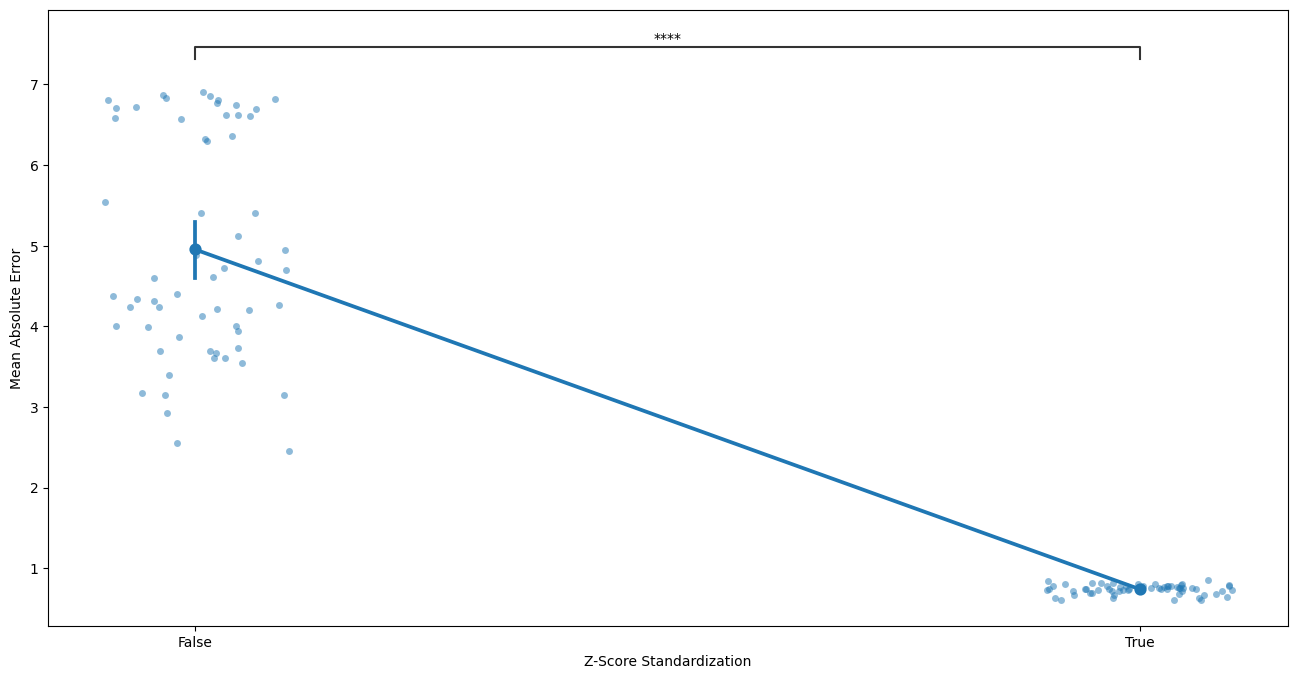

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.pointplot(data=df, x='znorm', y='value', ax=ax)
sns.stripplot(data=df, x="znorm", y="value", jitter=True, ax=ax, alpha=0.5)
ax.set_xlabel("Z-Score Standardization")
ax.set_ylabel("Mean Absolute Error")

pairs = list(combinations(df['znorm'].dropna().unique(), 2))

Annotator(
    ax,
    pairs,
    data=df,
    x='znorm',
    y='value'
).configure(
    test='t-test_ind',
    text_format='star',
    # loc='outside',
    hide_non_significant=True
).apply_and_annotate()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

RawCounts vs. LogCounts: t-test independent samples, P_val:3.310e-10 t=8.412e+00
LogCounts vs. NBVST: t-test independent samples, P_val:1.487e-06 t=-5.696e+00
RawCounts vs. NBVST: t-test independent samples, P_val:2.602e-06 t=5.519e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



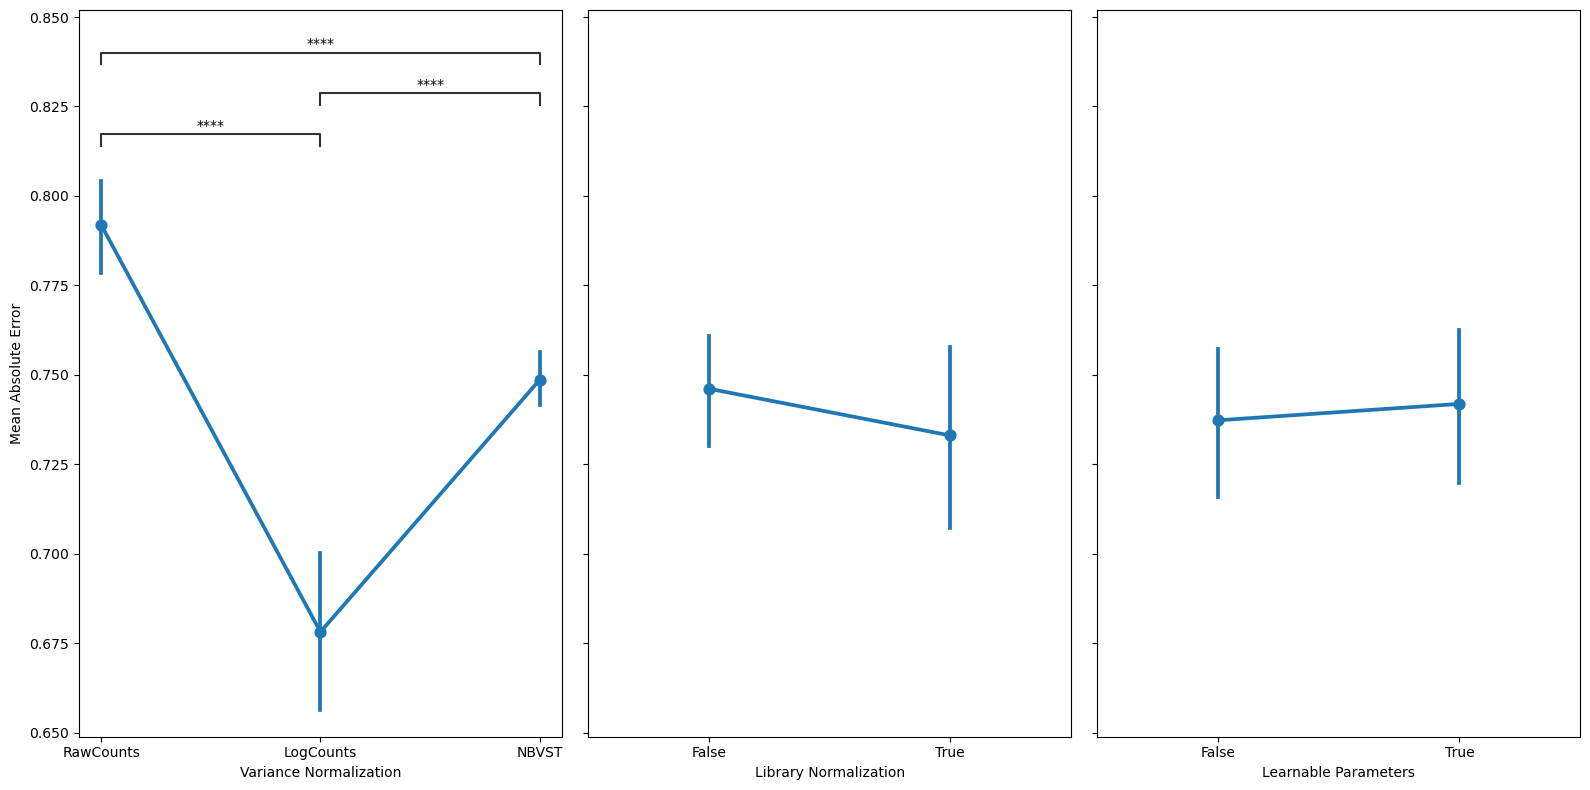

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

sns.pointplot(data=df2, x='norm_class', y='value', ax=axes[0])
sns.pointplot(data=df2, x='libnorm', y='value', ax=axes[1])
sns.pointplot(data=df2, x='learnable', y='value', ax=axes[2])

axes[0].set_xlabel("Variance Normalization")
axes[0].set_ylabel("Mean Absolute Error")

axes[1].set_xlabel("Library Normalization")
axes[1].set_ylabel("")

axes[2].set_xlabel("Learnable Parameters")
axes[2].set_ylabel("")

# all pairwise comparisons
pairs_embed = list(combinations(df2['norm_class'].dropna().unique(), 2))
pairs_hidden = list(combinations(df2['libnorm'].dropna().unique(), 2))
pairs_lr = list(combinations(df2['learnable'].dropna().unique(), 2))

# norm_class stats
Annotator(
    axes[0],
    pairs_embed,
    data=df2,
    x='norm_class',
    y='value'
).configure(
    test='t-test_ind',
    text_format='star',
    # loc='outside',
    hide_non_significant=True
).apply_and_annotate()

# libnorm stats
Annotator(
    axes[1],
    pairs_hidden,
    data=df2,
    x='libnorm',
    y='value'
).configure(
    test='t-test_ind',
    text_format='star',
    # loc='outside',
    hide_non_significant=True
).apply_and_annotate()

# learnable stats
Annotator(
    axes[2],
    pairs_lr,
    data=df2,
    x='learnable',
    y='value'
).configure(
    test='t-test_ind',
    text_format='star',
    # loc='outside',
    hide_non_significant=True
).apply_and_annotate()

plt.tight_layout()

---

In [10]:
# test_filt = g2a.test[~((g2a.test['norm_class']=='RawCounts') & (g2a.test['znorm']==False))]
test_filt = g2a.test[~(g2a.test['znorm']==False)]

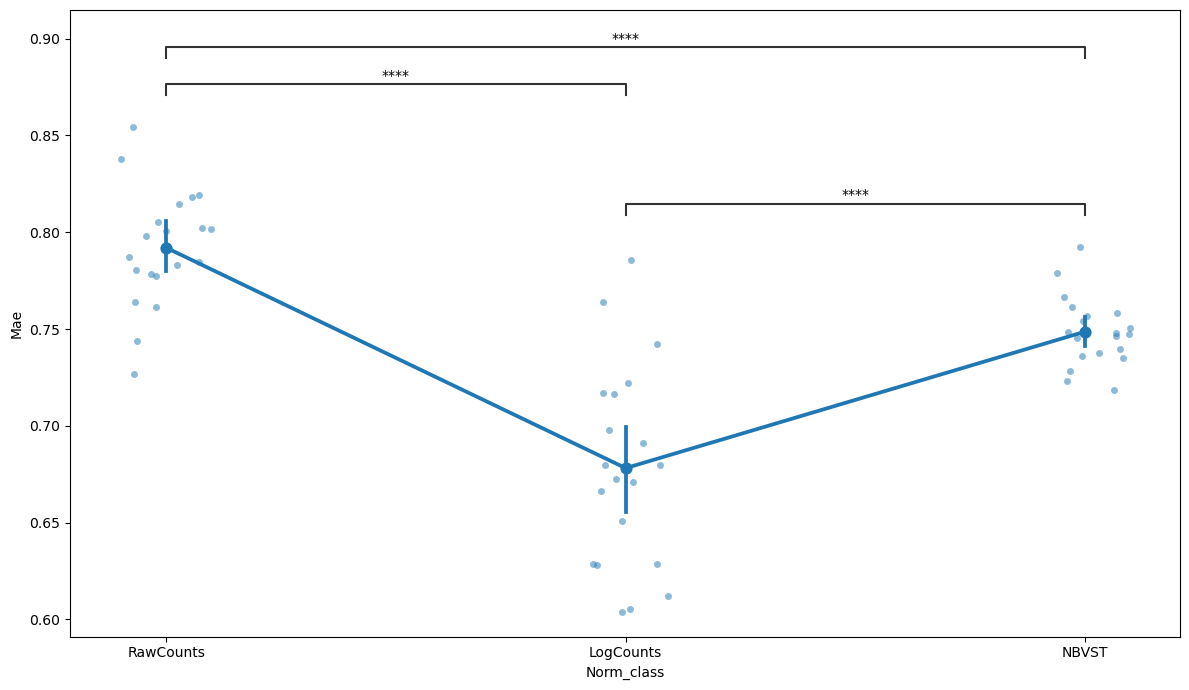

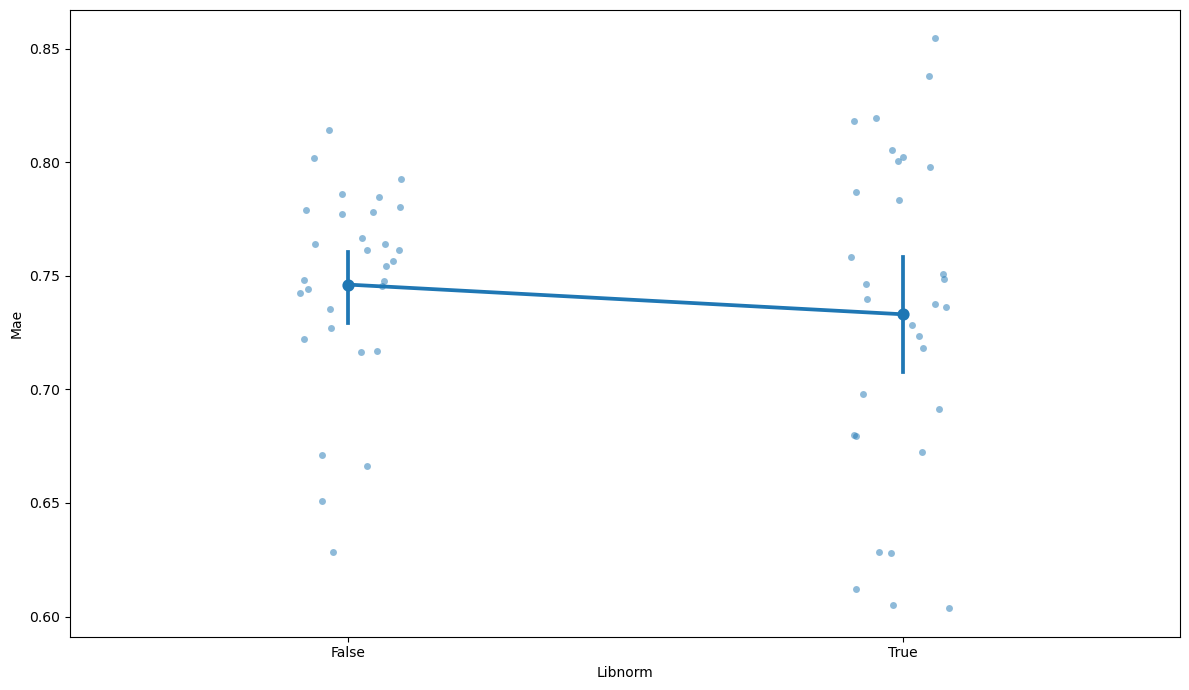

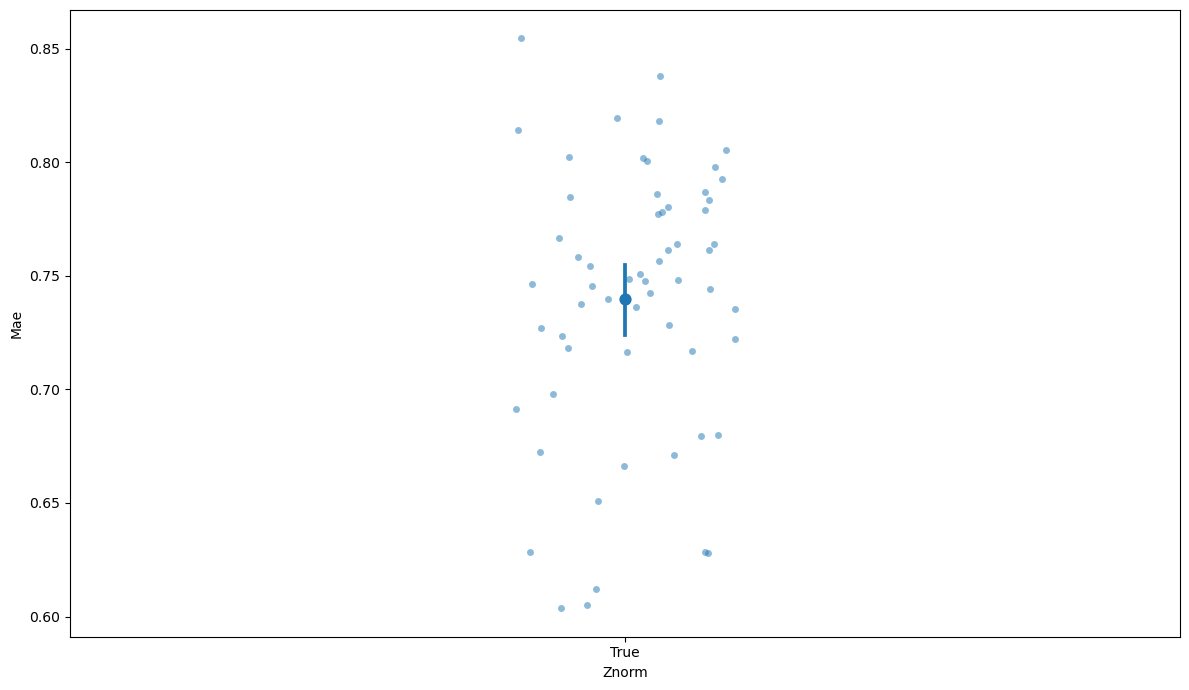

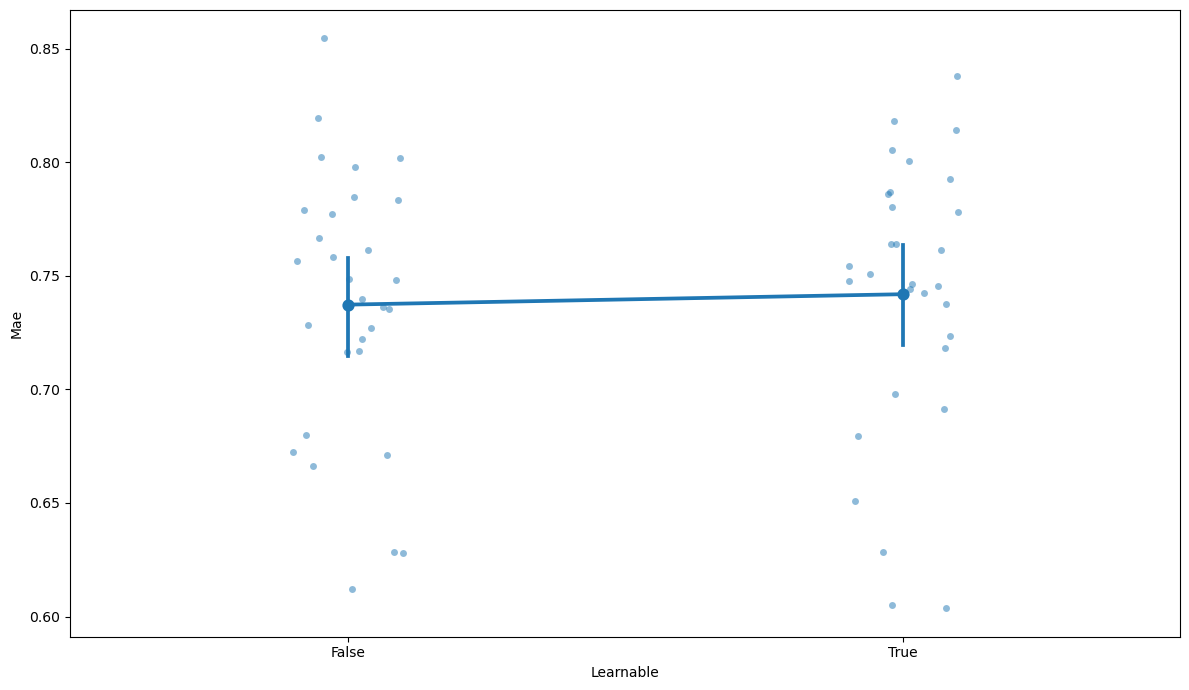

In [11]:
metric_x_point(
    df=test_filt,
    cols=g2a.keys,
    metrics=['mae'],
    figsize=(12,7),
    strip=True
)

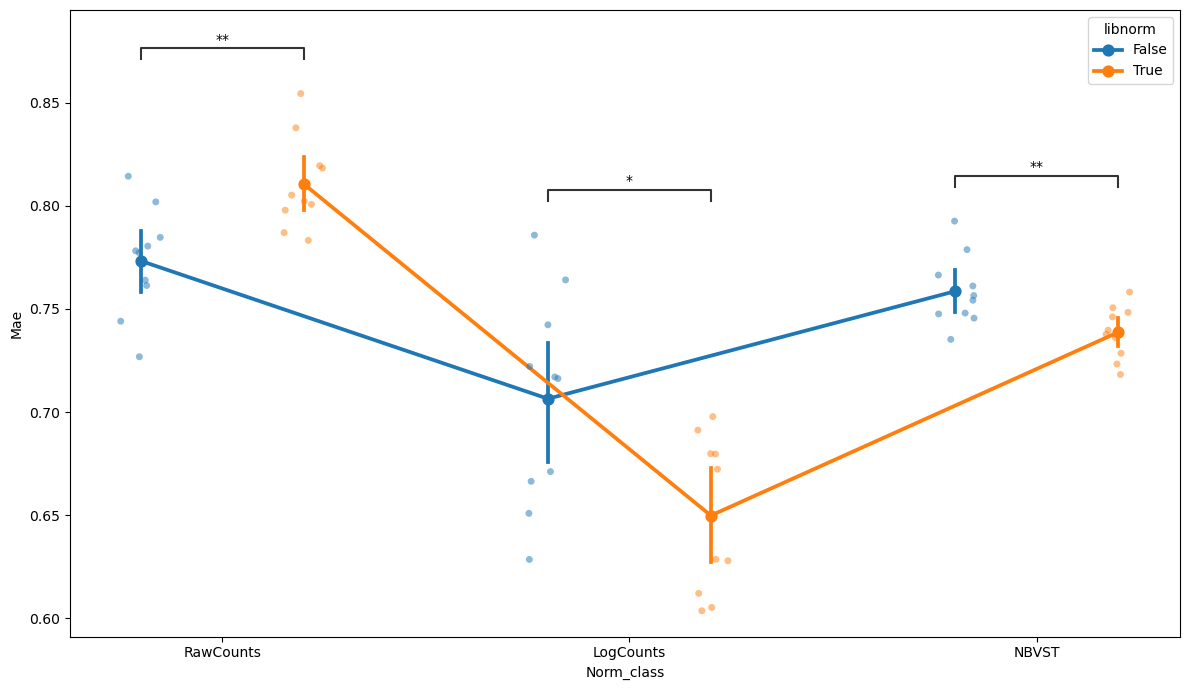

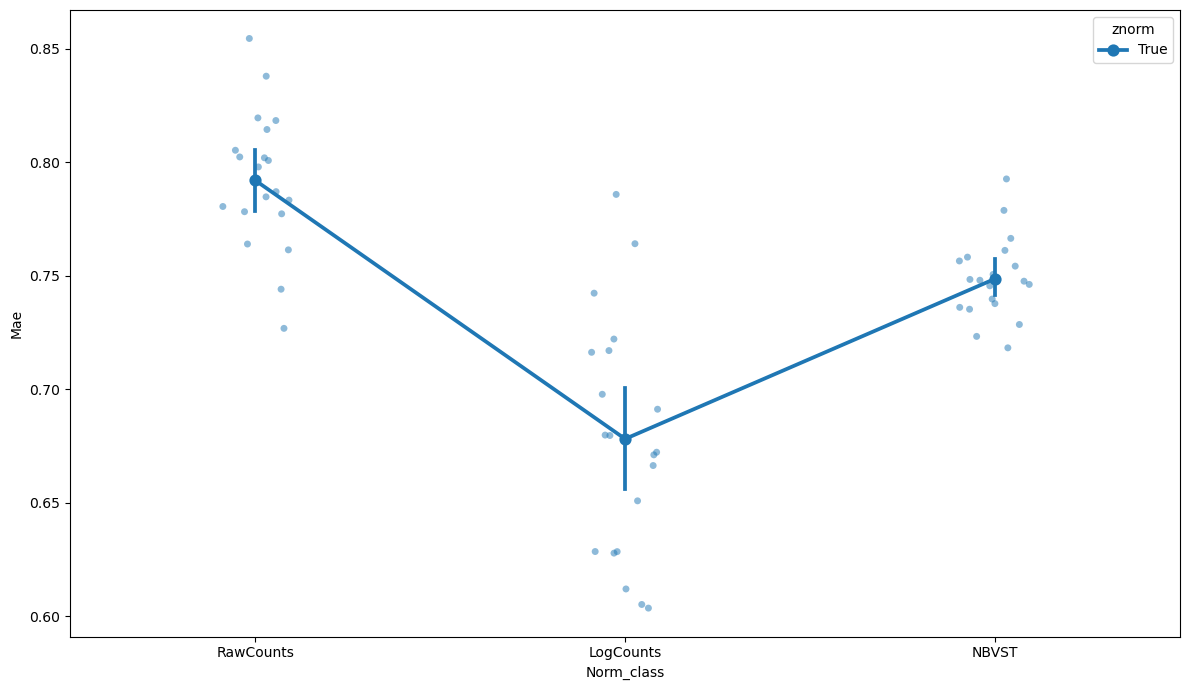

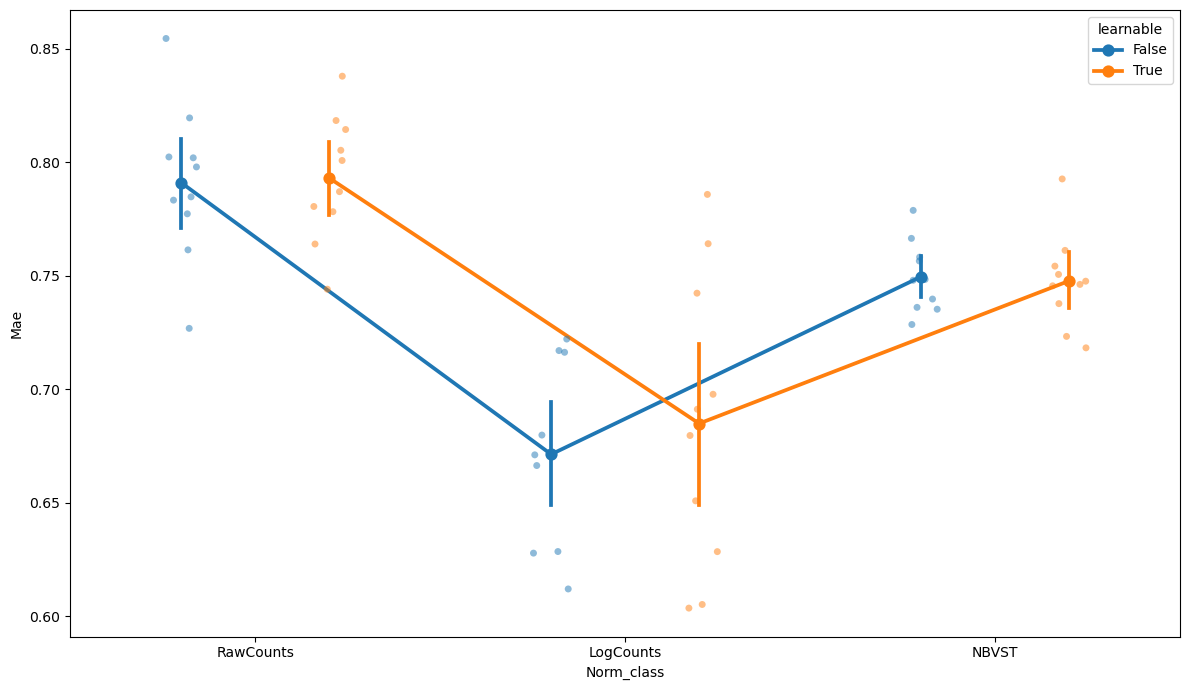

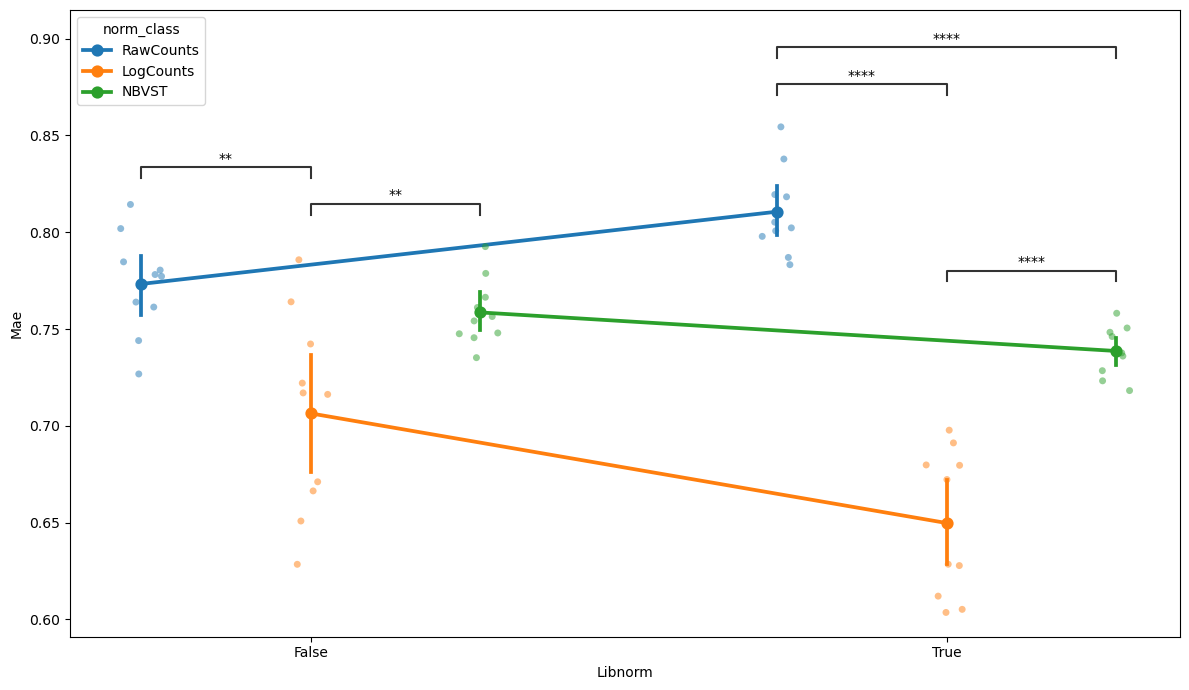

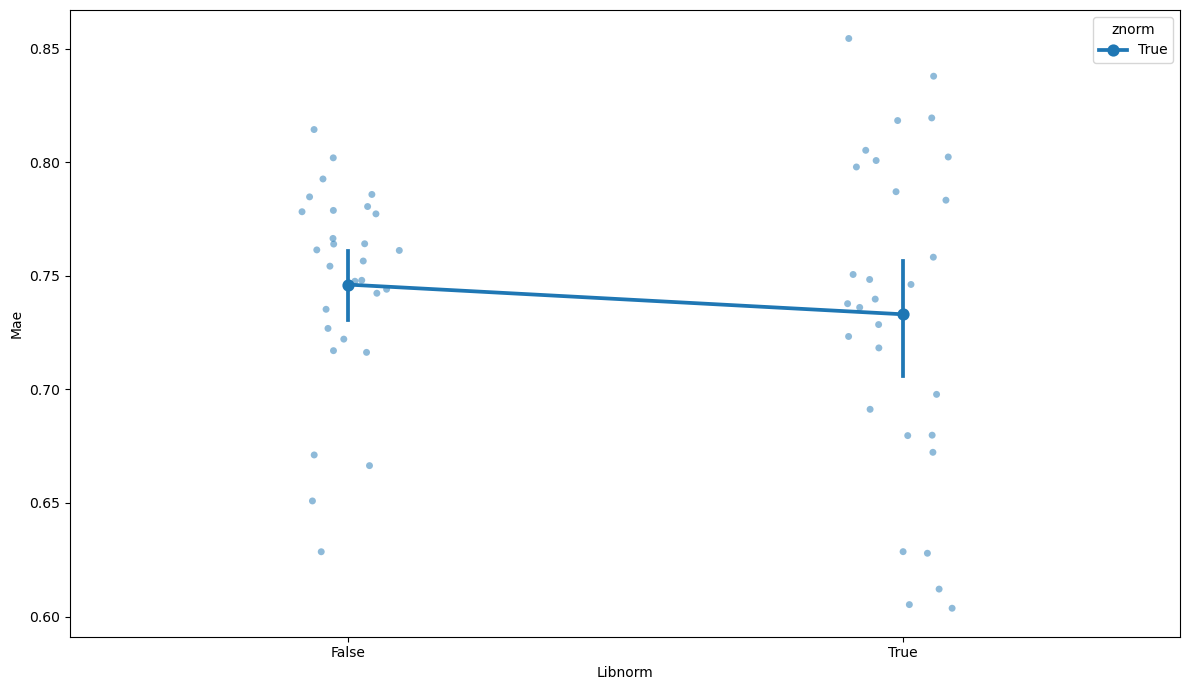

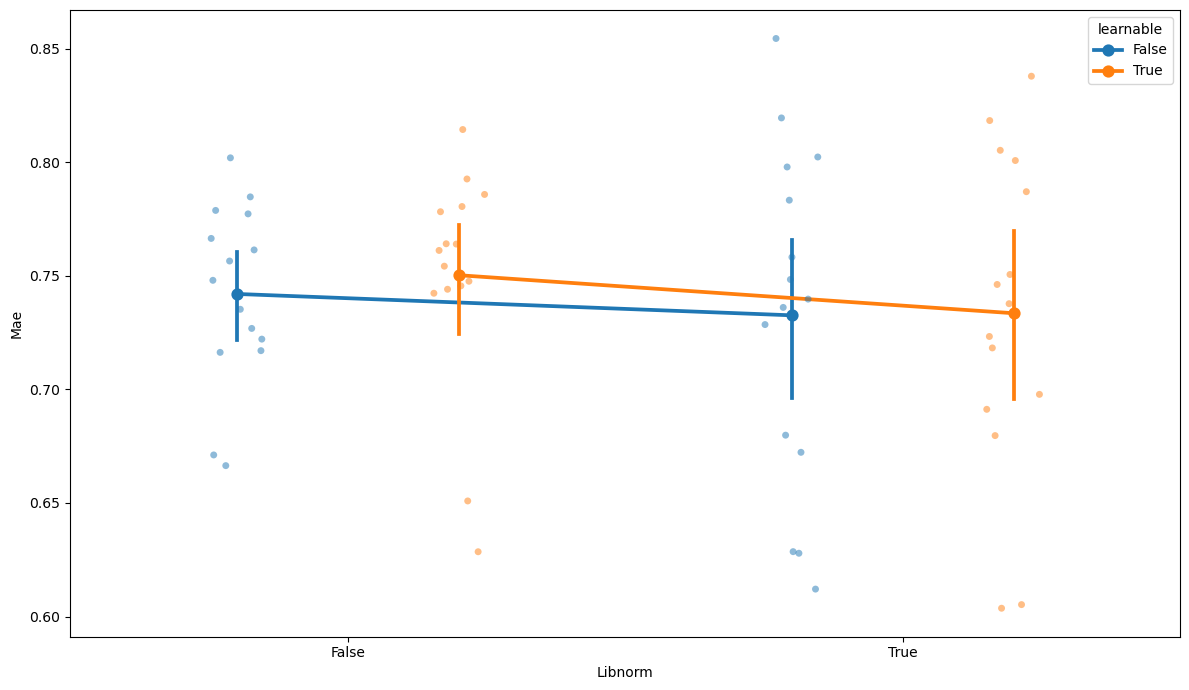

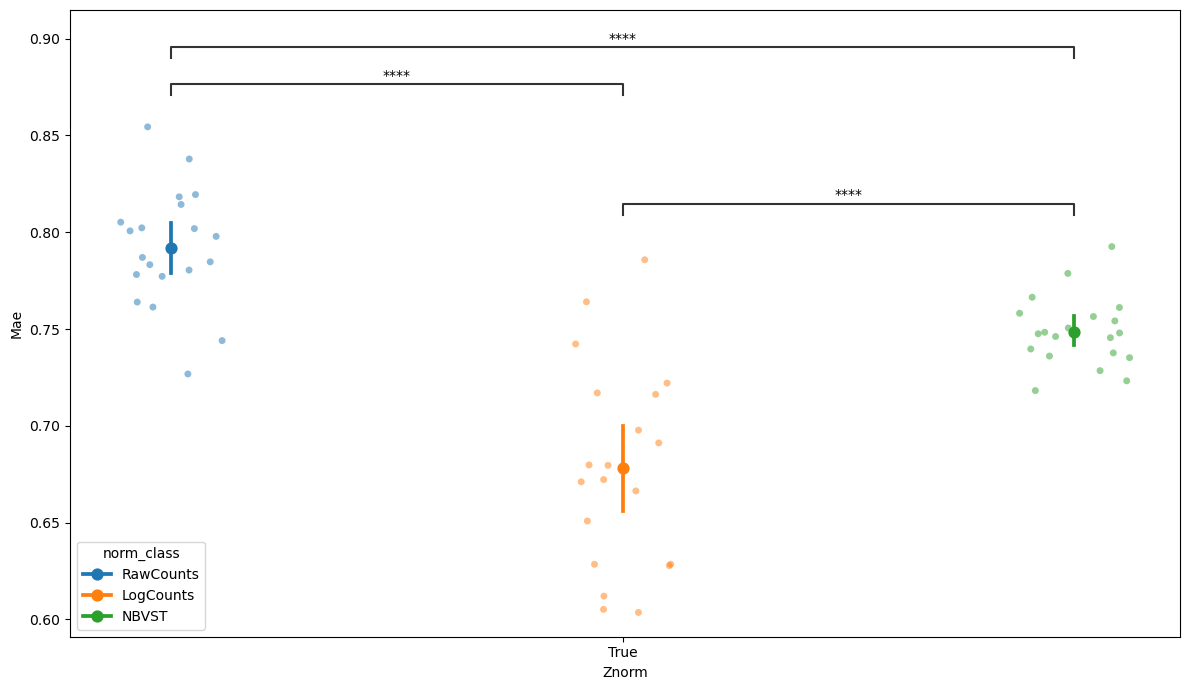

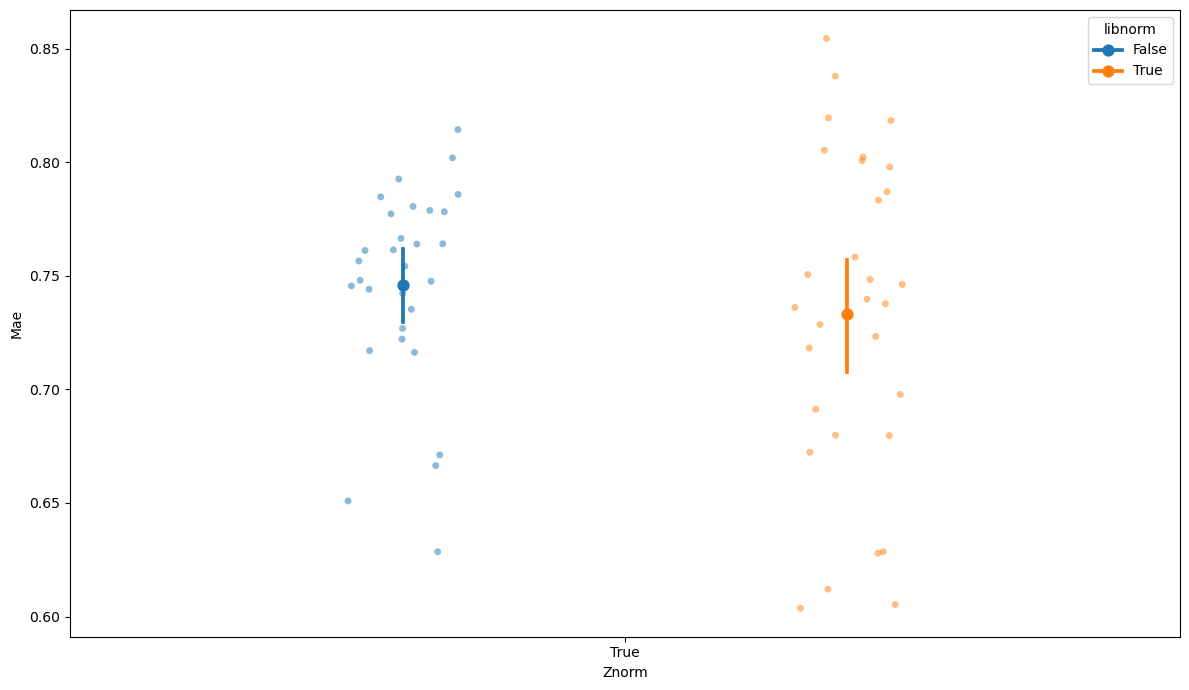

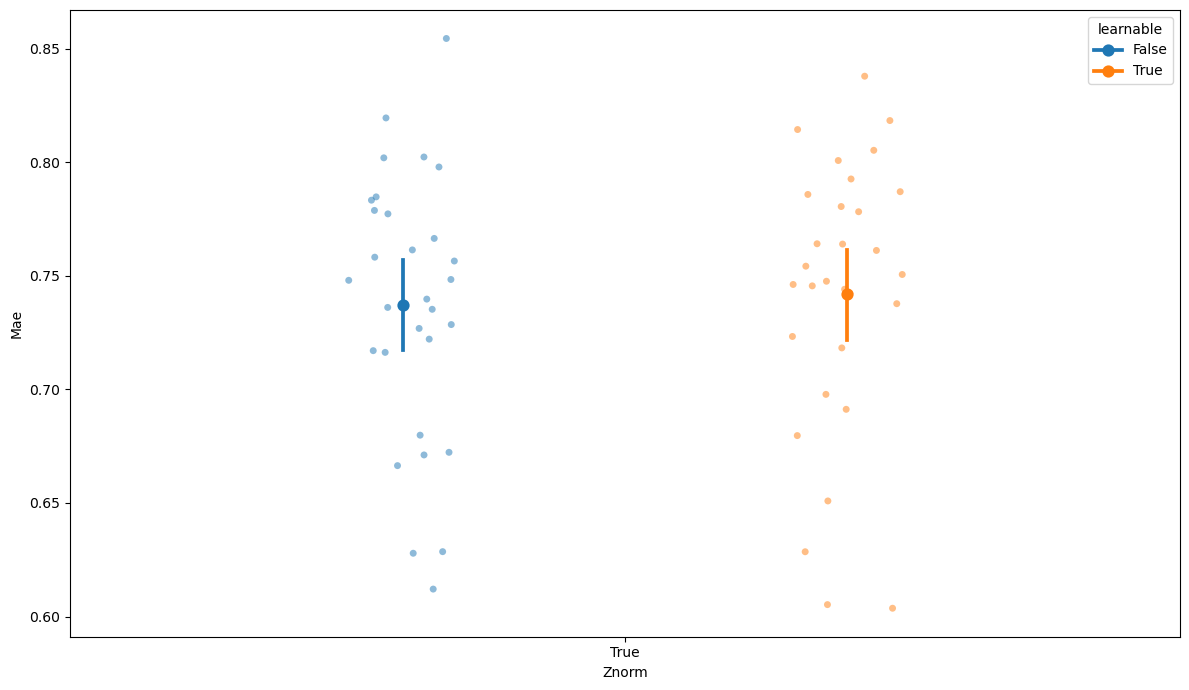

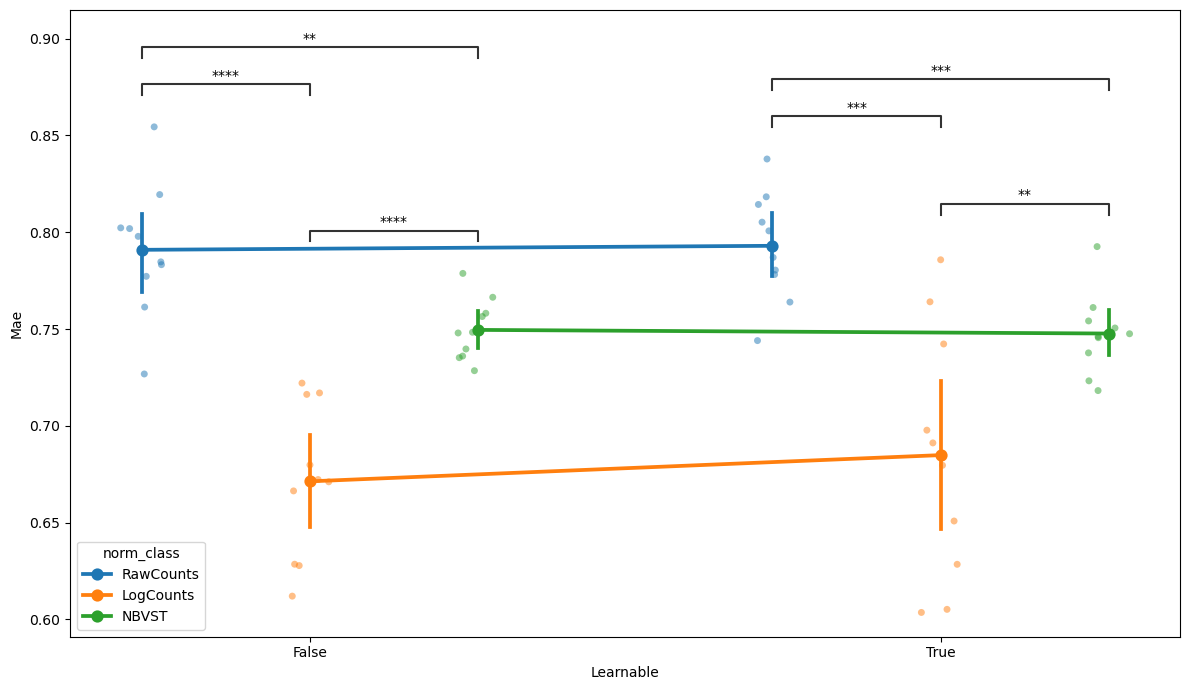

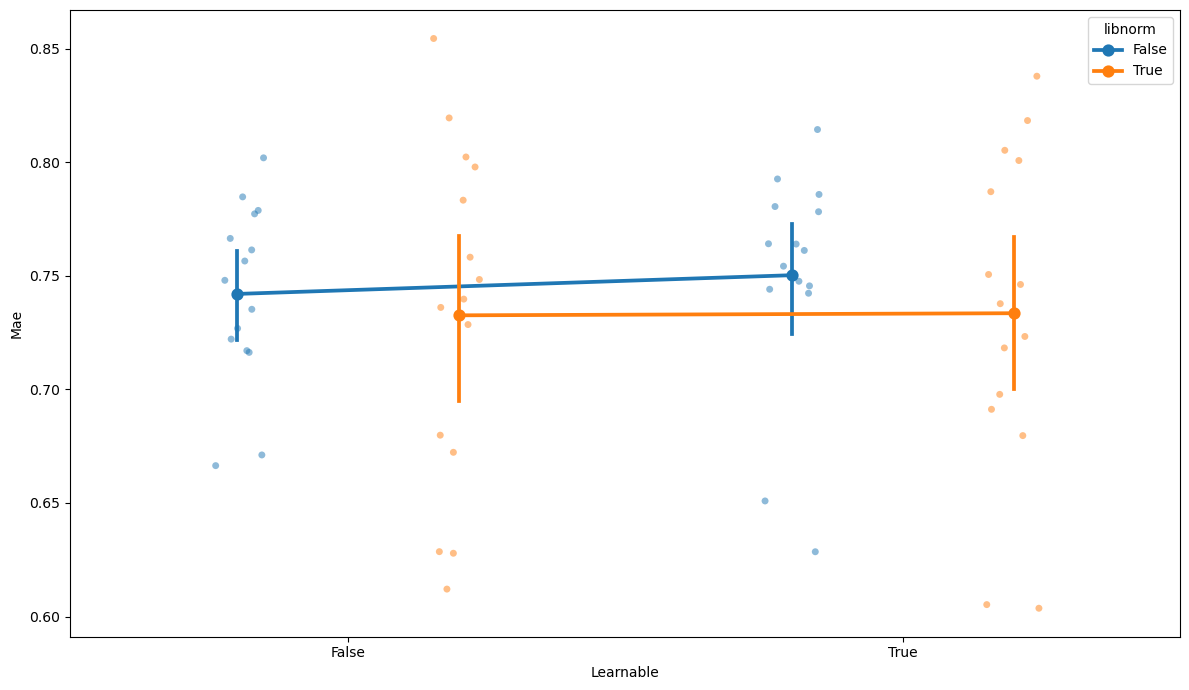

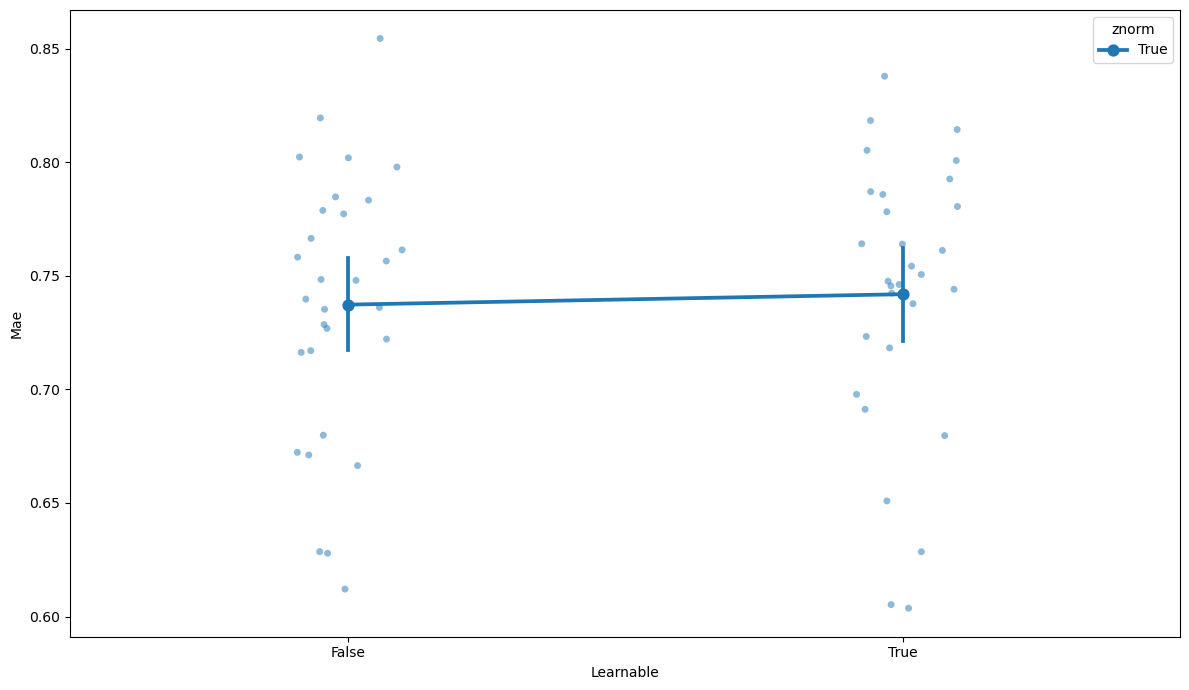

In [12]:
metric_x_point(
    df=test_filt,
    cols=g2a.keys,
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    hue=True
)